In [3]:
!pip install torch transformers shap matplotlib seaborn scikit-learn pandas numpy tqdm -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaConfig, RobertaForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import os
import random
import re
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.patches as mpatches

In [5]:
df = pd.read_csv('datasetma.csv')
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = text.lower()
    words = text.split()

    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess_text)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['text'])
similarity_matrix = cosine_similarity(tfidf_matrix)

threshold = 0.90
to_remove = set()

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if similarity_matrix[i, j] > threshold:
            to_remove.add(j)

df_cleaned = df.drop(list(to_remove)).reset_index(drop=True)
print("\nOriginal size:", len(df))
print("After removing near-duplicates:", len(df_cleaned))


# PRINT RANDOM SAMPLES
print("\nSAMPLE CLEANED TEXT:\n")

for i in range(5):
    print("=" * 60)
    print("Original :", df_cleaned.iloc[i]['text'])
    print("Cleaned  :", df_cleaned.iloc[i]['clean_text'])


Original size: 2591
After removing near-duplicates: 2590

SAMPLE CLEANED TEXT:

Original : I feel so empty that I just want to disappear and never come back.
Cleaned  : i feel so empty that i just want to disappear and never come back.
Original : My existence is a burden; I just want to disappear.
Cleaned  : my existence is a burden; i just want to disappear.
Original : If I disappear please tell my sister I love her.
Cleaned  : if i disappear please tell my sister i love her.
Original : He made me feel so small I just wanted to disappear forever.
Cleaned  : he made me feel so small i just wanted to disappear forever.
Original : I wish I could disappear so the world could be at peace without me.
Cleaned  : i wish i could disappear so the world could be at peace without me.


In [6]:
duplicates_data = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if similarity_matrix[i, j] > threshold:
            duplicates_data.append({
                "keyword" : df.iloc[i]['keyword'],
                "index_1": i,
                "text_1": df.iloc[i]['text'],
                "index_2": j,
                "text_2": df.iloc[j]['text'],
                "similarity": similarity_matrix[i, j]
            })

duplicates_df = pd.DataFrame(duplicates_data)
duplicates_df.to_csv("duplicates_found.csv", index=False)

print("Saved duplicates to duplicates_found.csv")



print(df_cleaned.columns)

print("\nLabel distribution:")
print(df['label'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())
df_train, df_temp = train_test_split(df_cleaned,test_size=0.30,random_state=42,stratify=df_cleaned['label'])
df_val, df_test = train_test_split(df_temp,test_size=0.50,random_state=42,stratify=df_temp['label'])

print(f"Training data shape: {df_train.shape}")
print(f"Validation data shape: {df_val.shape}")
print(f"Test data shape: {df_test.shape}")


Saved duplicates to duplicates_found.csv
Index(['id', 'text', 'keyword', 'label', 'clean_text'], dtype='str')

Label distribution:
label
non-risky    1370
risky        1221
Name: count, dtype: int64

Missing values:
id            0
text          0
keyword       0
label         0
clean_text    0
dtype: int64
Training data shape: (1813, 5)
Validation data shape: (388, 5)
Test data shape: (389, 5)


Train label distribution:
 label
non-risky    958
risky        855
Name: count, dtype: int64

Val label distribution:
 label
non-risky    205
risky        183
Name: count, dtype: int64

Test label distribution:
 label
non-risky    206
risky        183
Name: count, dtype: int64
Number of unique label: 2
Unique label: <StringArray>
['non-risky', 'risky']
Length: 2, dtype: str


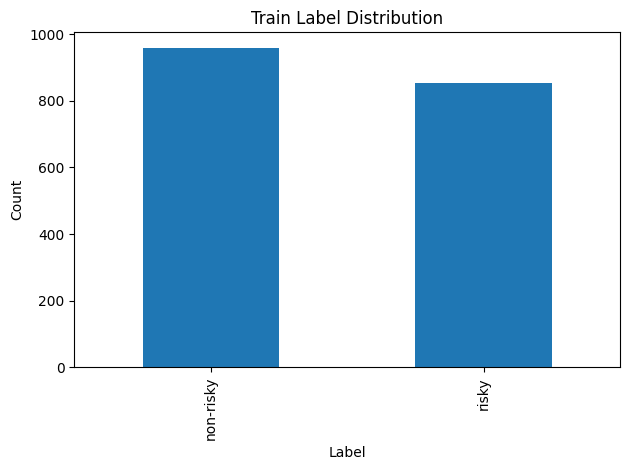

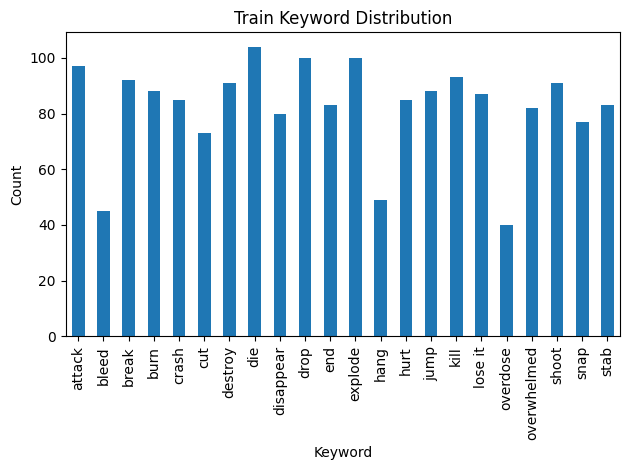

In [7]:
print("Train label distribution:\n", df_train['label'].value_counts())
print("\nVal label distribution:\n", df_val['label'].value_counts())
print("\nTest label distribution:\n", df_test['label'].value_counts())

unique_intents = df_train['label'].unique()
num_unique_intents = df_train['label'].nunique()

print(f"Number of unique label: {num_unique_intents}")
print(f"Unique label: {unique_intents}")

df_train.groupby('label').size().plot.bar()

plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Train Label Distribution')

plt.tight_layout()
plt.show()

df_train.groupby('keyword').size().plot.bar()

plt.xlabel('Keyword')
plt.ylabel('Count')
plt.title('Train Keyword Distribution')

plt.tight_layout()
plt.show()

In [8]:

# LONGEST text
longest_idx = df_train['clean_text'].str.len().idxmax()
longest_text = df_train.loc[longest_idx, 'clean_text']

print("Longest text:")
print(longest_text)
print("Length:", len(longest_text))


# SHORTEST text
shortest_idx = df_train['clean_text'].str.len().idxmin()
shortest_text = df_train.loc[shortest_idx, 'clean_text']

print("\nShortest text:")
print(shortest_text)
print("Length:", len(shortest_text))


# Encode labels
label_encoder = LabelEncoder()

df_train['encoded_label'] = label_encoder.fit_transform(df_train['label'])
df_val['encoded_label'] = label_encoder.transform(df_val['label'])
df_test['encoded_label'] = label_encoder.transform(df_test['label'])

# Split into arrays
train_texts = df_train['clean_text'].values
train_labels = df_train['encoded_label'].values

val_texts = df_val['clean_text'].values
val_labels = df_val['encoded_label'].values

test_texts = df_test['clean_text'].values
test_labels = df_test['encoded_label'].values


print(df_train['clean_text'].head())

Longest text:
i want to finish my final project perfectly so i can die with honour, metaphorically speaking.
Length: 94

Shortest text:
i wanna stab him
Length: 16
1165    the laser can destroy tiny defects on the surface
2123    i want to jump off the tracks of this project ...
440             i accidentally snapped the plastic ruler.
1727              they said they might stab the classmate
1833                      she wants to hurt her boyfriend
Name: clean_text, dtype: str


In [9]:
from types import SimpleNamespace

configss = SimpleNamespace(max_len=64,batch_size=16,learning_rate=2e-5,num_epochs=5,dropout=0.3,
    patience=3,random_seed=42,model_name="roberta-base")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(configss.random_seed)
np.random.seed(configss.random_seed)
print(f"Device: {device}")


Device: cuda


In [10]:
# ── Dataset ────────────────────────────────────────────────
class IntentDataset(Dataset):
    def __init__(self, texts, intents, tokenizer, max_len=configss.max_len):
        self.texts = texts
        self.intents = intents
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        intent = self.intents[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'intent': torch.tensor(intent, dtype=torch.long)
        }

print("IntentDataset defined!")

IntentDataset defined!


In [11]:
# ── Tokenizer & Data Loaders ───────────────────────────────
tokenizer = RobertaTokenizer.from_pretrained(configss.model_name)

train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
val_dataset   = IntentDataset(val_texts,   val_labels,   tokenizer)
test_dataset  = IntentDataset(test_texts,  test_labels,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=configss.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=configss.batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=configss.batch_size)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("Tokenizer and loaders ready!")

Train batches : 114
Val batches   : 25
Test batches  : 25
Tokenizer and loaders ready!


In [12]:
# ── Global Evaluation Helper ───────────────────────────────
def evaluate_model(model, data_loader, device, title="Test", model_type="standard"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["intent"].to(device)

            # handle both standard and contrastive models
            if model_type == "contrastive":
                logits, _, _ = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                logits = model(input_ids=input_ids, attention_mask=attention_mask)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted'
    )

    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds,
          target_names=label_encoder.classes_))

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

print("evaluate_model defined!")

evaluate_model defined!


In [13]:
# ── Global Predict Helper ──────────────────────────────────
def predict_intent(text, model, device, model_type="standard"):
    model.eval()
    cleaned = preprocess_text(text)
    encoding = tokenizer(
        cleaned,
        add_special_tokens=True,
        max_length=configss.max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        if model_type == "contrastive":
            logits, _, _ = model(input_ids=input_ids, attention_mask=attention_mask)
        else:
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

        prob_risky = torch.softmax(logits, dim=1)[0][1].item()
        predicted  = torch.argmax(logits, dim=1).item()

    return {
        "label"     : label_encoder.inverse_transform([predicted])[0],
        "prob_risky": prob_risky,
        "prob_safe" : 1 - prob_risky
    }


def predict_batch(texts, expected_labels, model, device, model_type="standard"):
    """Test multiple sentences and show results cleanly"""
    print(f"{'='*65}")
    print(f"  PREDICTIONS")
    print(f"{'='*65}")

    correct = 0
    for text, expected in zip(texts, expected_labels):
        result  = predict_intent(text, model, device, model_type)
        is_correct = result['label'] == expected
        if is_correct:
            correct += 1
        status  = "✓" if is_correct else "✗"
        print(f"{status} '{text}'")
        print(f"   Expected: {expected:<12} | "
              f"Predicted: {result['label']:<12} | "
              f"Risky prob: {result['prob_risky']:.4f}")
    
    print(f"\nAccuracy: {correct}/{len(texts)} ({correct/len(texts)*100:.0f}%)")

print("predict_intent and predict_batch defined!")

predict_intent and predict_batch defined!


In [14]:
# ── Global SHAP Helper ─────────────────────────────────────
def get_shap_explainer(model, device, model_type="standard"):
    """Create SHAP explainer for any model"""
    
    def predict_proba(texts):
        model.eval()
        probs_all = []

        for text in texts:
            cleaned = preprocess_text(text)
            encoding = tokenizer(
                cleaned,
                add_special_tokens=True,
                max_length=configss.max_len,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors='pt'
            )
            input_ids      = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)

            with torch.no_grad():
                if model_type == "contrastive":
                    logits, _, _ = model(input_ids=input_ids, attention_mask=attention_mask)
                else:
                    logits = model(input_ids=input_ids, attention_mask=attention_mask)

                probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

            probs_all.append(probs)

        return np.array(probs_all)

    explainer = shap.Explainer(predict_proba, tokenizer)
    return explainer


def shap_waterfall(explainer, text, title=""):
    """Run SHAP and show waterfall plot for a single sentence"""
    shap_values = explainer([text])
    prob = shap_values[0, :, 1].base_values + shap_values[0, :, 1].values.sum()

    print(f"\nSentence : '{text}'")
    print(f"Predicted risky probability: {prob:.4f}")
    if title:
        print(f"Model    : {title}")

    shap.plots.waterfall(shap_values[0, :, 1], max_display=10)
    return prob


def shap_compare(explainers_dict, text):
    """Compare SHAP across multiple models for same sentence"""
    print(f"\n{'='*60}")
    print(f"SHAP COMPARISON: '{text}'")
    print(f"{'='*60}")

    for model_name, explainer in explainers_dict.items():
        print(f"\n--- {model_name} ---")
        shap_waterfall(explainer, text, title=model_name)

print("SHAP helpers defined!")

SHAP helpers defined!


In [15]:
# ── Global PCA Latent Space Helper ────────────────────────
def plot_latent_space(model, dataset, device, title="Latent Space", 
                      n_samples=300, model_type="standard"):
    """Visualize latent space using PCA"""
    model.eval()
    embeddings = []
    labels     = []

    n_samples = min(n_samples, len(dataset))

    with torch.no_grad():
        for i in range(n_samples):
            sample = dataset[i]
            input_ids      = sample['input_ids'].unsqueeze(0).to(device)
            attention_mask = sample['attention_mask'].unsqueeze(0).to(device)

            if model_type == "contrastive":
                _, _, cls_emb = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                cls_emb = cls_emb.squeeze().cpu().numpy()
            else:
                # access roberta directly for CLS embedding
                outputs = model.model.roberta(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                cls_emb = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

            embeddings.append(cls_emb)
            labels.append(sample['intent'].item())

    # PCA reduction
    pca     = PCA(n_components=2)
    reduced = pca.fit_transform(np.array(embeddings))

    # plot
    plt.figure(figsize=(8, 6))
    colors = ['blue' if l == 0 else 'red' for l in labels]
    plt.scatter(reduced[:, 0], reduced[:, 1], c=colors, alpha=0.6)
    plt.title(f"Latent Space — {title}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    legend = [
        mpatches.Patch(color='blue', label='non-risky'),
        mpatches.Patch(color='red',  label='risky')
    ]
    plt.legend(handles=legend)
    plt.tight_layout()
    plt.show()

    print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

print("plot_latent_space defined!")

plot_latent_space defined!


In [22]:
# ── Global Negation Test Helper ────────────────────────────
NEGATION_TEST_CASES = [
    # obvious risky — should be risky
    ("I want to die",                          "risky"),
    ("I want to kill myself",                  "risky"),
    ("I want to cut myself",                   "risky"),
    ("I want to end my life tonight",          "risky"),
    ("I want to jump off this building",       "risky"),
    # obvious non-risky — should be non-risky
    ("I want to die of laughter",              "non-risky"),
    ("I want to die of embarrassment",         "non-risky"),
    ("I want to kill it at this interview",    "non-risky"),
    ("I want to cut my hair",                  "non-risky"),
    ("I want to jump for joy",                 "non-risky"),
    # negation — should be non-risky
    ("I stopped wanting to die",               "non-risky"),
    ("I don't want to hurt myself anymore",    "non-risky"),
    ("I no longer feel like ending it all",    "non-risky"),
    ("I quit thinking about killing myself",   "non-risky"),
    ("I finally stopped cutting myself",       "non-risky"),
]

def test_negation(model, device, model_type="standard", title="Model"):
    print(f"\n{'='*65}")
    print(f"  TEST — {title}")
    print(f"{'='*65}")

    risky_correct    = 0
    nonrisky_correct = 0
    negation_correct = 0

    for i, (text, expected) in enumerate(NEGATION_TEST_CASES):
        result     = predict_intent(text, model, device, model_type)
        is_correct = result['label'] == expected

        if i < 5:
            category = "RISKY   "
            if is_correct: risky_correct += 1
        elif i < 10:
            category = "NON-RISK"
            if is_correct: nonrisky_correct += 1
        else:
            category = "NEGATION"
            if is_correct: negation_correct += 1

        status = "✓" if is_correct else "✗"
        print(f"{status} [{category}] '{text}'")
        print(f"         Expected: {expected:<12} | "
              f"Predicted: {result['label']:<12} | "
              f"Risky prob: {result['prob_risky']:.4f}")

    total = risky_correct + nonrisky_correct + negation_correct
    print(f"\n{'─'*65}")
    print(f"  Risky     : {risky_correct}/5")
    print(f"  Non-Risky : {nonrisky_correct}/5")
    print(f"  Negation  : {negation_correct}/5")
    print(f"  Overall   : {total}/15")

    return {
        "overall"  : total / 15,
        "negation" : negation_correct / 5,
        "ambiguous": nonrisky_correct / 5,
    }

print("NEGATION_TEST_CASES and test_negation updated!")

NEGATION_TEST_CASES and test_negation updated!


In [17]:
# ── Global Comparison Table Helper ────────────────────────
results_tracker = {}

def add_result(model_name, eval_results, negation_results=None):
    """Track results for all models"""
    results_tracker[model_name] = {
        "accuracy" : eval_results["accuracy"],
        "f1"       : eval_results["f1"],
        "precision": eval_results["precision"],
        "recall"   : eval_results["recall"],
        "negation" : negation_results["negation"]  if negation_results else None,
        "ambiguous": negation_results["ambiguous"] if negation_results else None,
    }

def print_comparison_table():
    """Print final comparison table of all models"""
    print(f"\n{'='*75}")
    print(f"  FINAL MODEL COMPARISON")
    print(f"{'='*75}")
    print(f"  {'Model':<30} {'Accuracy':>10} {'F1':>10} {'Negation':>10} {'Ambiguous':>10}")
    print(f"  {'-'*70}")

    for model_name, results in results_tracker.items():
        neg = f"{results['negation']:.0%}" if results['negation'] is not None else "N/A"
        amb = f"{results['ambiguous']:.0%}" if results['ambiguous'] is not None else "N/A"
        print(f"  {model_name:<30} "
              f"{results['accuracy']:>10.4f} "
              f"{results['f1']:>10.4f} "
              f"{neg:>10} "
              f"{amb:>10}")

    print(f"{'='*75}")

print("Comparison table helpers defined!")

Comparison table helpers defined!


In [18]:
# ============================================================
# EXPERIMENT 1: Pretrained RoBERTa — No Fine-Tuning
# ============================================================
from transformers import RobertaForSequenceClassification, RobertaConfig

class BaselineClassifier(nn.Module):
    def __init__(self, num_intent_classes, pretrained=True):
        super().__init__()
        if pretrained:
            self.model = RobertaForSequenceClassification.from_pretrained(
                configss.model_name,
                num_labels=num_intent_classes,
                hidden_dropout_prob=configss.dropout
            )
        else:
            config = RobertaConfig.from_pretrained(configss.model_name)
            config.num_labels = num_intent_classes
            config.hidden_dropout_prob = configss.dropout
            self.model = RobertaForSequenceClassification(config)

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

pretrained_only = BaselineClassifier(
    num_intent_classes=num_unique_intents,
    pretrained=True
).to(device)

print("Pretrained Only model ready!")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5096.71it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pretrained Only model ready!


EXPERIMENT 1: Pretrained RoBERTa — No Fine-Tuning

  Pretrained Only
  Accuracy  : 0.5296
  Precision : 0.2804
  Recall    : 0.5296
  F1 Score  : 0.3667

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.53      1.00      0.69       206
       risky       0.00      0.00      0.00       183

    accuracy                           0.53       389
   macro avg       0.26      0.50      0.35       389
weighted avg       0.28      0.53      0.37       389



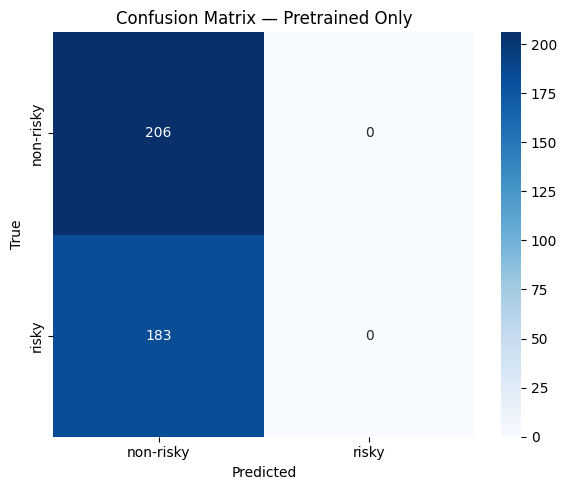


  TEST — Pretrained Only
✗ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: non-risky    | Risky prob: 0.4467
✗ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: non-risky    | Risky prob: 0.4438
✗ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: non-risky    | Risky prob: 0.4424
✗ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: non-risky    | Risky prob: 0.4444
✗ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: non-risky    | Risky prob: 0.4411
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.4433
✓ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.4454
✓ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.4395
✓ [NON-RI

In [23]:
print("=" * 60)
print("EXPERIMENT 1: Pretrained RoBERTa — No Fine-Tuning")
print("=" * 60)

pretrained_eval = evaluate_model(pretrained_only, test_loader, device, title="Pretrained Only")
pretrained_neg = test_negation(pretrained_only, device, title="Pretrained Only")

add_result("Pretrained Only", pretrained_eval, pretrained_neg)

print_comparison_table()

In [24]:
# SHAP for Pretrained Only
explainer_pretrained = get_shap_explainer(pretrained_only, device, model_type="standard")
print("SHAP explainer ready!")

SHAP explainer ready!



Sentence : 'I want to die.'
Predicted risky probability: 0.4420
Model    : Pretrained Only


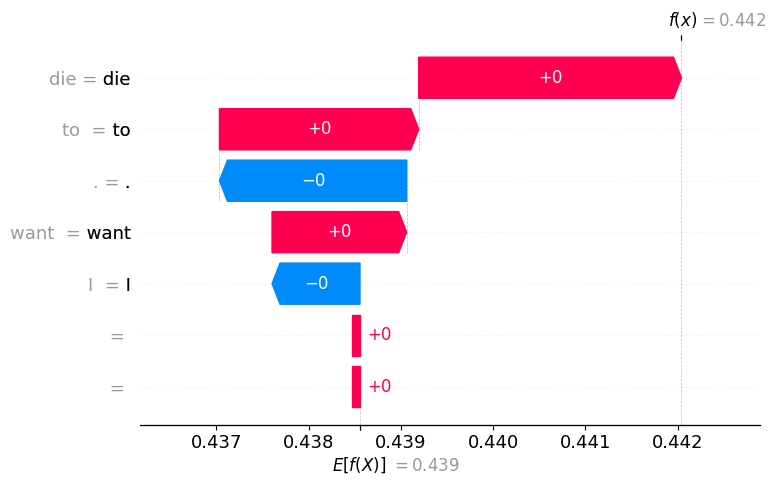


Sentence : 'I want to die of embarrassment.'
Predicted risky probability: 0.4400
Model    : Pretrained Only


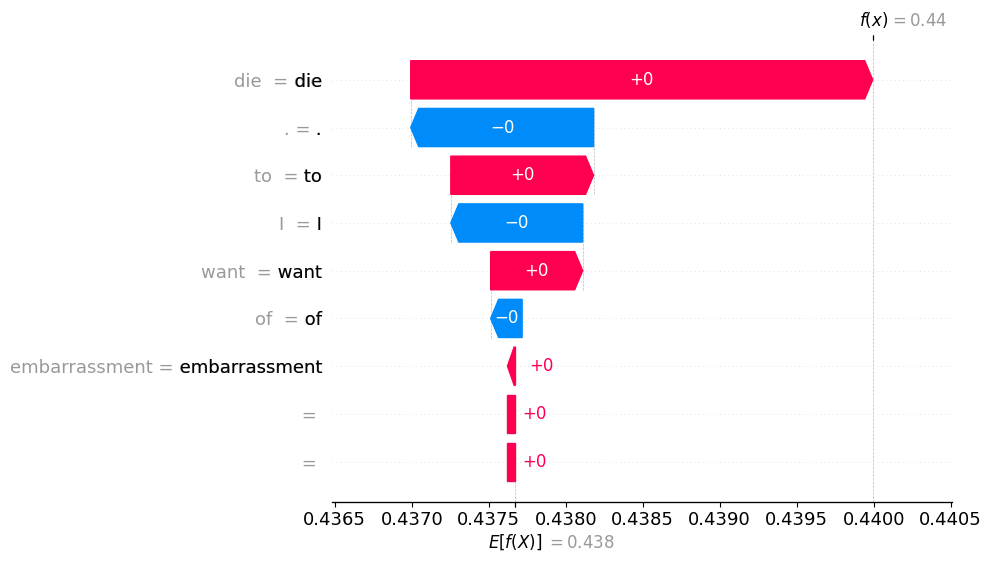


Sentence : 'I don't want to die.'
Predicted risky probability: 0.4408
Model    : Pretrained Only


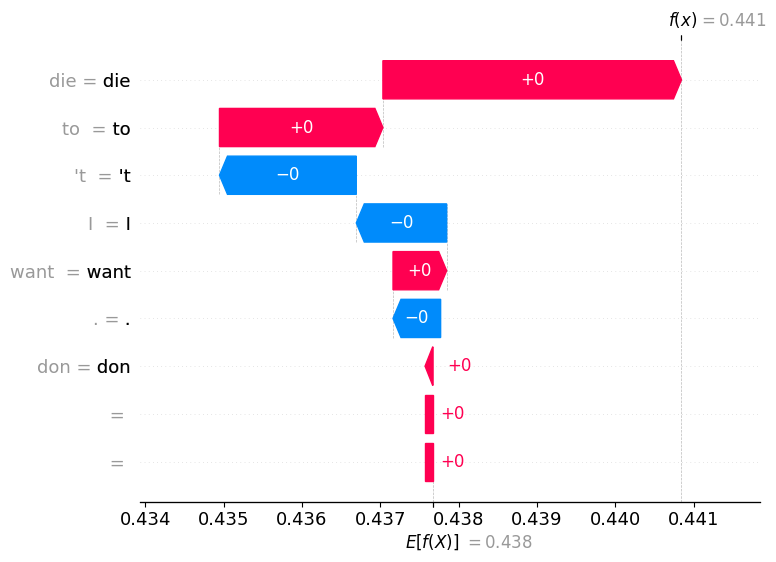

In [26]:
sentences = [
    "I want to die.",
    "I want to die of embarrassment.",
    "I don't want to die.",
]

for text in sentences:
    shap_waterfall(explainer_pretrained, text, title="Pretrained Only")


Sentence : 'I want to eat ice cream.'
Predicted risky probability: 0.4382
Model    : Pretrained Only


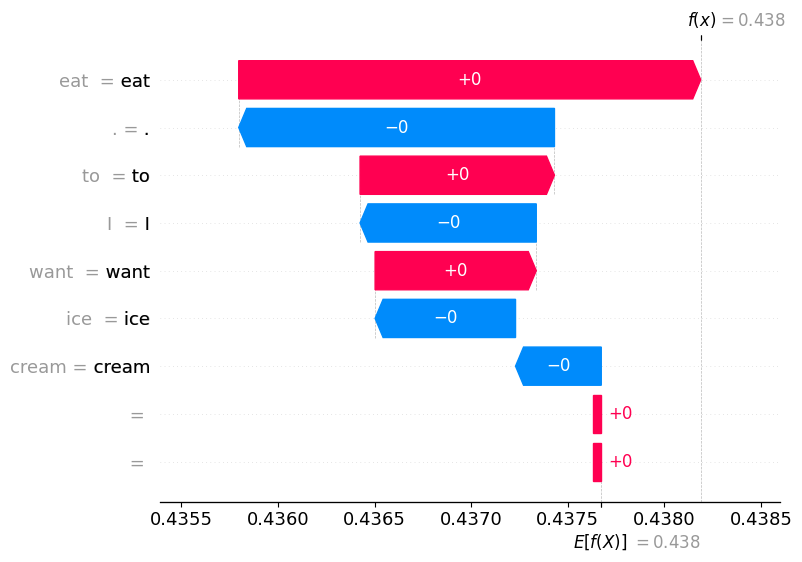

np.float64(0.43818843364715576)

In [27]:
# compare risky vs non-risky with same keyword
shap_waterfall(explainer_pretrained, "I want to eat ice cream.", title="Pretrained Only")

In [28]:
# ============================================================
# EXPERIMENT 2: Fine-Tuned RoBERTa
# ============================================================
class IntentClassifier(nn.Module):
    def __init__(self, num_intent_classes, model_name=configss.model_name, dropout=configss.dropout):
        super().__init__()
        self.model = RobertaForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_intent_classes,
            hidden_dropout_prob=dropout
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

ft_model = IntentClassifier(num_intent_classes=num_unique_intents).to(device)
print("Fine-Tuned RoBERTa model ready!")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4633.11it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-Tuned RoBERTa model ready!


In [29]:
def train_model(model, train_loader, val_loader, device, num_epochs=configss.num_epochs, model_type="standard"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=configss.learning_rate, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_accuracy = 0
    best_model = None
    epochs_without_improvement = 0

    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for i, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['intent'].to(device)

            optimizer.zero_grad()

            if model_type == "contrastive":
                logits, _, _ = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                logits = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

            print(f"  Epoch {epoch+1}/{num_epochs} | Batch {i+1}/{len(train_loader)} | Loss: {total_loss/(i+1):.4f}", end='\r', flush=True)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # validation
        model.eval()
        val_correct = 0
        val_total   = 0
        val_loss_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['intent'].to(device)

                if model_type == "contrastive":
                    logits, _, _ = model(input_ids=input_ids, attention_mask=attention_mask)
                else:
                    logits = model(input_ids=input_ids, attention_mask=attention_mask)

                loss = criterion(logits, labels)
                val_loss_total += loss.item()
                _, predicted = torch.max(logits, 1)
                val_correct  += (predicted == labels).sum().item()
                val_total    += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc  = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{num_epochs} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"  ✓ New best! Val Acc={val_acc:.4f}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= configss.patience:
            print(f"Early stopping!")
            break

        scheduler.step()

    return best_model, best_val_accuracy, history

print("train_model defined!")

train_model defined!


In [30]:
print("=" * 60)
print("EXPERIMENT 2: Training Fine-Tuned RoBERTa")
print("=" * 60)

best_ft_state, best_ft_acc, ft_history = train_model(ft_model, train_loader, val_loader, device)

torch.save({
    'model_state_dict': best_ft_state,
    'accuracy': best_ft_acc,
    'history': ft_history
}, 'ft_model.pth')

print(f"\nBest validation accuracy: {best_ft_acc:.4f}")
print("Model saved to ft_model.pth!")

EXPERIMENT 2: Training Fine-Tuned RoBERTa
  Epoch 1/5 | Batch 114/114 | Loss: 0.6402
Epoch 1/5 | Train Loss=0.6402 | Val Loss=0.2905 | Train Acc=0.6073 | Val Acc=0.8814
  ✓ New best! Val Acc=0.8814
  Epoch 2/5 | Batch 114/114 | Loss: 0.3484
Epoch 2/5 | Train Loss=0.3484 | Val Loss=0.1279 | Train Acc=0.8566 | Val Acc=0.9588
  ✓ New best! Val Acc=0.9588
  Epoch 3/5 | Batch 114/114 | Loss: 0.2554
Epoch 3/5 | Train Loss=0.2554 | Val Loss=0.1387 | Train Acc=0.9178 | Val Acc=0.9588
  Epoch 4/5 | Batch 114/114 | Loss: 0.2054
Epoch 4/5 | Train Loss=0.2054 | Val Loss=0.1203 | Train Acc=0.9366 | Val Acc=0.9691
  ✓ New best! Val Acc=0.9691
  Epoch 5/5 | Batch 114/114 | Loss: 0.1507
Epoch 5/5 | Train Loss=0.1507 | Val Loss=0.1509 | Train Acc=0.9586 | Val Acc=0.9665

Best validation accuracy: 0.9691
Model saved to ft_model.pth!



  Fine-Tuned RoBERTa
  Accuracy  : 0.9589
  Precision : 0.9602
  Recall    : 0.9589
  F1 Score  : 0.9589

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.98      0.94      0.96       206
       risky       0.93      0.98      0.96       183

    accuracy                           0.96       389
   macro avg       0.96      0.96      0.96       389
weighted avg       0.96      0.96      0.96       389



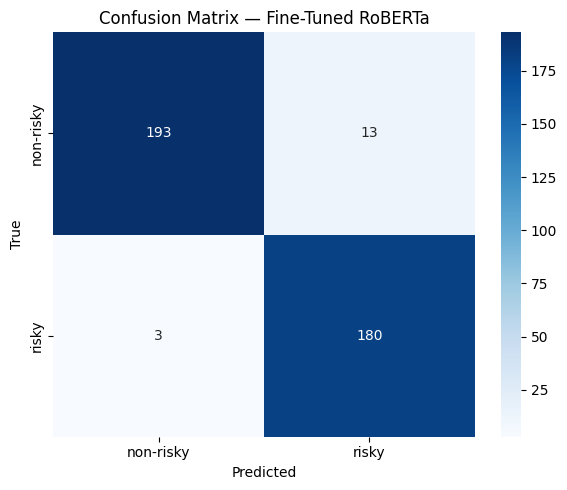


  TEST — Fine-Tuned RoBERTa
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9982
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9984
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9985
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0035
✓ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0275
✓ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0052
✓ [NON

In [31]:
ft_model.load_state_dict(best_ft_state)

ft_eval = evaluate_model(ft_model, test_loader, device, title="Fine-Tuned RoBERTa")
ft_neg  = test_negation(ft_model, device, title="Fine-Tuned RoBERTa")
add_result("Fine-Tuned RoBERTa", ft_eval, ft_neg)

print_comparison_table()

In [32]:
explainer_ft = get_shap_explainer(ft_model, device, model_type="standard")
print("SHAP explainer ready!")

SHAP explainer ready!



Sentence : 'I want to die.'
Predicted risky probability: 0.9978
Model    : Fine-Tuned RoBERTa


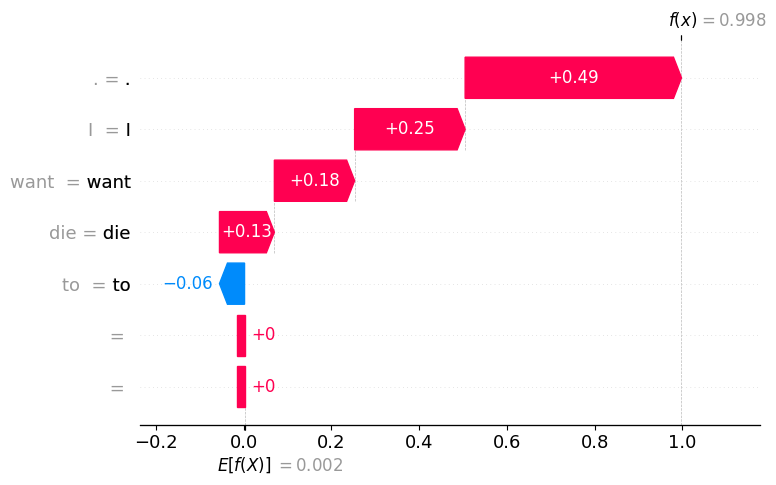


Sentence : 'I want to die of embarrassment.'
Predicted risky probability: 0.2414
Model    : Fine-Tuned RoBERTa


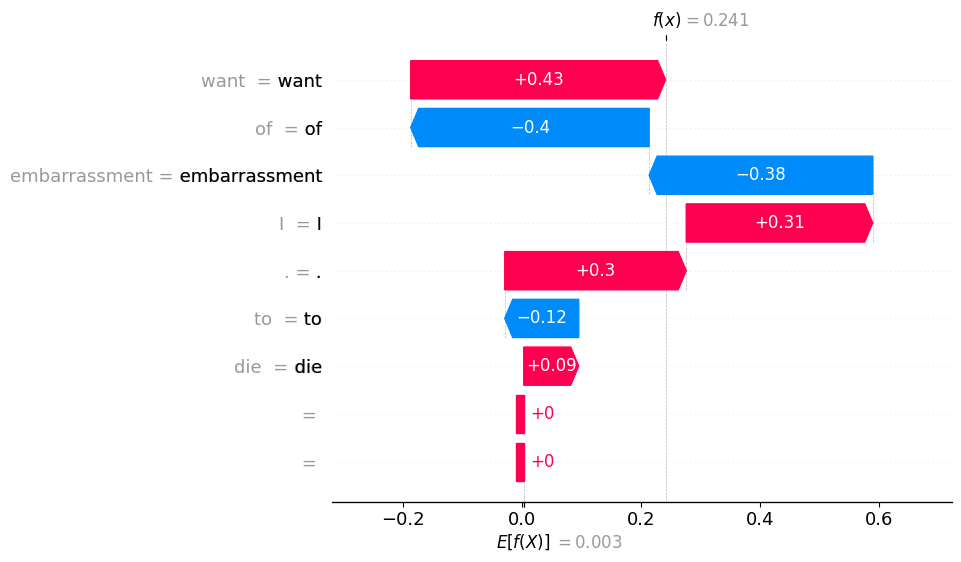


Sentence : 'I don't want to die.'
Predicted risky probability: 0.9971
Model    : Fine-Tuned RoBERTa


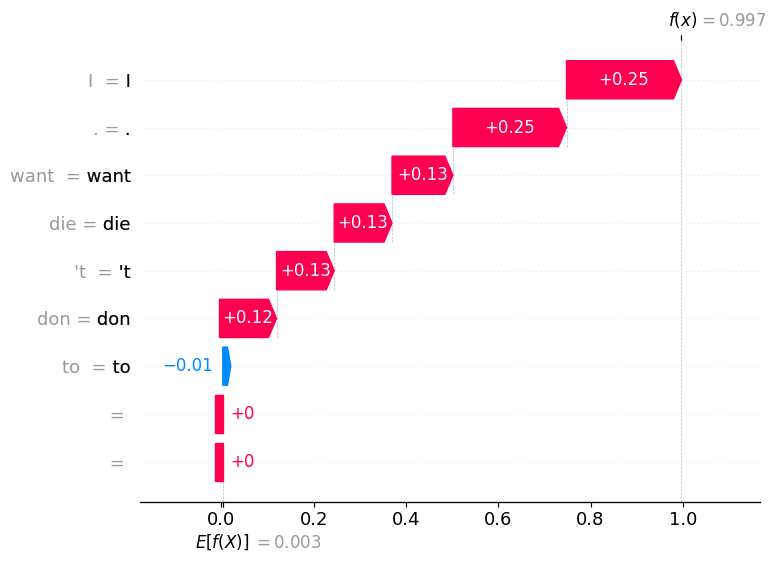

In [33]:
sentences = [
    "I want to die.",
    "I want to die of embarrassment.",
    "I don't want to die.",
]

for text in sentences:
    shap_waterfall(explainer_ft, text, title="Fine-Tuned RoBERTa")

In [34]:
# ============================================================
# EXPERIMENT 3: NLI RoBERTa — Zero Shot
# ============================================================
from transformers import pipeline

nli_pipeline = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-roberta-base",
    device=0
)

print("=" * 60)
print("EXPERIMENT 3: NLI RoBERTa — Zero Shot")
print("=" * 60)

# evaluate on test set
all_preds  = []
all_labels = []

for i, row in df_test.iterrows():
    result    = nli_pipeline(
        row['text'],
        candidate_labels=["risky", "non-risky"],
        hypothesis_template="This sentence expresses {} intent."
    )
    predicted = result['labels'][0]
    all_preds.append(predicted)
    all_labels.append(row['label'])

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted'
)

print(f"\nAccuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['non-risky', 'risky']))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4538.87it/s]
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


EXPERIMENT 3: NLI RoBERTa — Zero Shot

Accuracy  : 0.5039
Precision : 0.6748
Recall    : 0.5039
F1 Score  : 0.3816

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.84      0.08      0.14       206
       risky       0.49      0.98      0.65       183

    accuracy                           0.50       389
   macro avg       0.66      0.53      0.40       389
weighted avg       0.67      0.50      0.38       389



In [35]:
# NLI negation test
print("=" * 60)
print("EXPERIMENT 3: NLI Zero-Shot — Negation Test")
print("=" * 60)

nli_negation_correct    = 0
nli_risky_correct       = 0
nli_nonrisky_correct    = 0

for i, (text, expected) in enumerate(NEGATION_TEST_CASES):
    result    = nli_pipeline(
        text,
        candidate_labels=["risky", "non-risky"],
        hypothesis_template="This sentence expresses {} intent."
    )
    predicted = result['labels'][0]
    score     = result['scores'][0]
    is_correct = predicted == expected

    if i < 5:
        category = "RISKY   "
        if is_correct: nli_risky_correct += 1
    elif i < 10:
        category = "NON-RISK"
        if is_correct: nli_nonrisky_correct += 1
    else:
        category = "NEGATION"
        if is_correct: nli_negation_correct += 1

    status = "✓" if is_correct else "✗"
    print(f"{status} [{category}] '{text}'")
    print(f"         Expected: {expected:<12} | Predicted: {predicted:<12} | Score: {score:.3f}")

total = nli_risky_correct + nli_nonrisky_correct + nli_negation_correct
print(f"\n{'─'*65}")
print(f"  Risky     : {nli_risky_correct}/5")
print(f"  Non-Risky : {nli_nonrisky_correct}/5")
print(f"  Negation  : {nli_negation_correct}/5")
print(f"  Overall   : {total}/15")

nli_eval = {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}
nli_neg  = {"overall": total/15, "negation": nli_negation_correct/5, "ambiguous": nli_nonrisky_correct/5}

add_result("NLI Zero-Shot", nli_eval, nli_neg)
print_comparison_table()

EXPERIMENT 3: NLI Zero-Shot — Negation Test
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Score: 0.994
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Score: 0.996
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Score: 0.992
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Score: 0.958
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Score: 0.992
✗ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: risky        | Score: 0.984
✗ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: risky        | Score: 0.989
✗ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: risky        | Score: 0.991
✗ [NON-RISK] 'I want to cut my hair'
  

In [36]:
def predict_proba_nli(texts):
    probs_all = []
    for text in texts:
        result = nli_pipeline(
            text,
            candidate_labels=["risky", "non-risky"],
            hypothesis_template="This sentence expresses {} intent."
        )
        prob_risky    = result['scores'][0] if result['labels'][0] == 'risky' else 1 - result['scores'][0]
        prob_nonrisky = 1 - prob_risky
        probs_all.append([prob_nonrisky, prob_risky])
    return np.array(probs_all)

explainer_nli = shap.Explainer(predict_proba_nli, tokenizer)
print("SHAP explainer for NLI Zero-Shot ready!")

SHAP explainer for NLI Zero-Shot ready!



Sentence : 'I want to die.'
Predicted risky probability: 0.9928
Model    : NLI Zero-Shot


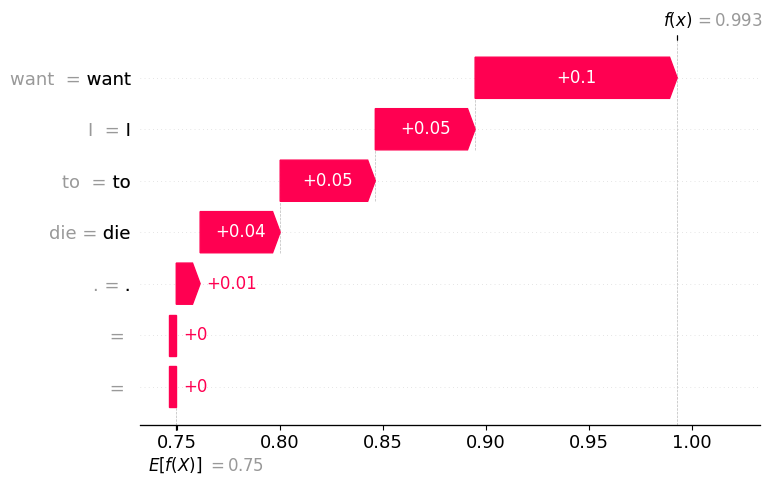


Sentence : 'I want to die of embarrassment.'
Predicted risky probability: 0.9887
Model    : NLI Zero-Shot


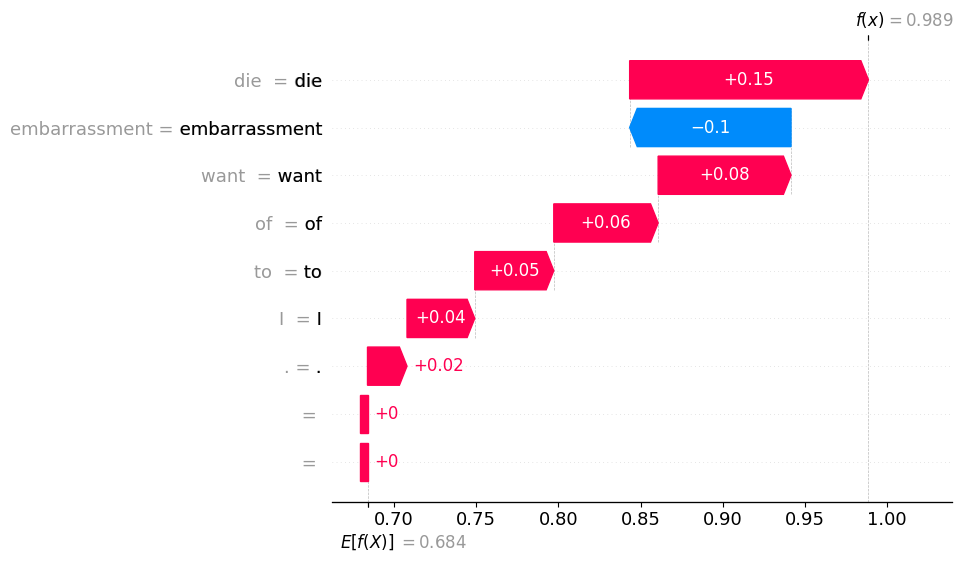


Sentence : 'I don't want to die.'
Predicted risky probability: 0.4247
Model    : NLI Zero-Shot


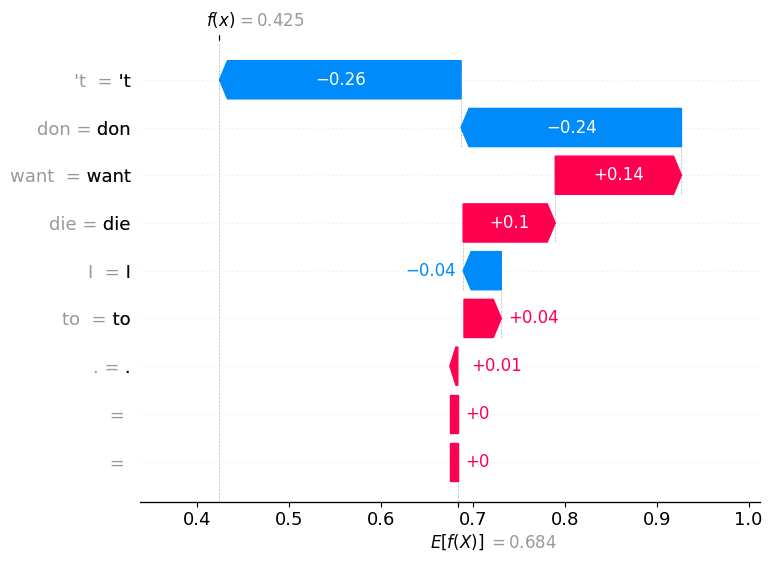

In [37]:
sentences = [
    "I want to die.",
    "I want to die of embarrassment.",
    "I don't want to die.",
]

for text in sentences:
    shap_waterfall(explainer_nli, text, title="NLI Zero-Shot")

In [47]:
# ============================================================
# EXPERIMENT 4A: Fine-Tuned NLI RoBERTa
# ============================================================
from transformers import RobertaModel

class NLIFineTuned(nn.Module):
    def __init__(self, num_intent_classes, dropout=configss.dropout):
        super().__init__()
        # starts from NLI weights instead of vanilla roberta!
        self.model = RobertaForSequenceClassification.from_pretrained(
            "cross-encoder/nli-roberta-base",
            num_labels=num_intent_classes,
            hidden_dropout_prob=dropout,
            ignore_mismatched_sizes=True
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

nli_ft_model = NLIFineTuned(num_intent_classes=num_unique_intents).to(device)
print("NLI Fine-Tuned model ready!")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4818.39it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


NLI Fine-Tuned model ready!


In [48]:
print("=" * 60)
print("EXPERIMENT 4A: Training NLI Fine-Tuned RoBERTa")
print("=" * 60)

best_nli_ft_state, best_nli_ft_acc, nli_ft_history = train_model(
    nli_ft_model, train_loader, val_loader, device
)

torch.save({
    'model_state_dict': best_nli_ft_state,
    'accuracy': best_nli_ft_acc,
    'history': nli_ft_history
}, 'nli_ft_model.pth')

print(f"\nBest validation accuracy: {best_nli_ft_acc:.4f}")
print("Model saved to nli_ft_model.pth!")

EXPERIMENT 4A: Training NLI Fine-Tuned RoBERTa
  Epoch 1/5 | Batch 114/114 | Loss: 0.4419
Epoch 1/5 | Train Loss=0.4419 | Val Loss=0.3248 | Train Acc=0.7954 | Val Acc=0.9098
  ✓ New best! Val Acc=0.9098
  Epoch 2/5 | Batch 114/114 | Loss: 0.2086
Epoch 2/5 | Train Loss=0.2086 | Val Loss=0.2918 | Train Acc=0.9316 | Val Acc=0.9381
  ✓ New best! Val Acc=0.9381
  Epoch 3/5 | Batch 114/114 | Loss: 0.2046
Epoch 3/5 | Train Loss=0.2046 | Val Loss=0.1769 | Train Acc=0.9443 | Val Acc=0.9459
  ✓ New best! Val Acc=0.9459
  Epoch 4/5 | Batch 114/114 | Loss: 0.1368
Epoch 4/5 | Train Loss=0.1368 | Val Loss=0.1921 | Train Acc=0.9653 | Val Acc=0.9536
  ✓ New best! Val Acc=0.9536
  Epoch 5/5 | Batch 114/114 | Loss: 0.0925
Epoch 5/5 | Train Loss=0.0925 | Val Loss=0.2207 | Train Acc=0.9746 | Val Acc=0.9510

Best validation accuracy: 0.9536
Model saved to nli_ft_model.pth!



  NLI Fine-Tuned
  Accuracy  : 0.9614
  Precision : 0.9644
  Recall    : 0.9614
  F1 Score  : 0.9615

Classification Report:
              precision    recall  f1-score   support

   non-risky       1.00      0.93      0.96       206
       risky       0.92      1.00      0.96       183

    accuracy                           0.96       389
   macro avg       0.96      0.96      0.96       389
weighted avg       0.96      0.96      0.96       389



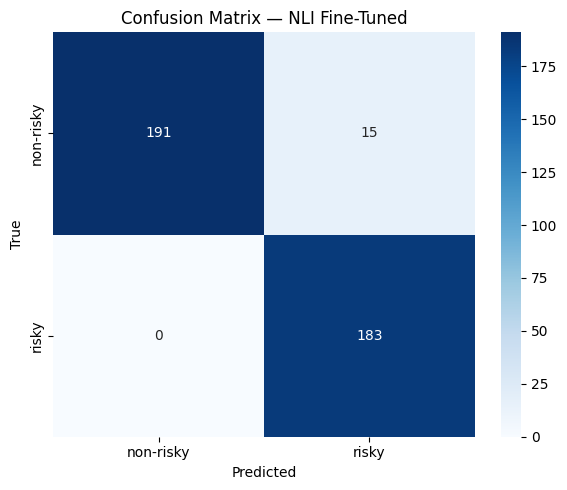


  TEST — NLI Fine-Tuned
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0006
✓ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0010
✗ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: risky        | Risky prob: 0.9656
✓ [NON-RIS

In [49]:
nli_ft_model.load_state_dict(best_nli_ft_state)

nli_ft_eval = evaluate_model(nli_ft_model, test_loader, device, title="NLI Fine-Tuned")
nli_ft_neg  = test_negation(nli_ft_model, device, title="NLI Fine-Tuned")
add_result("NLI Fine-Tuned", nli_ft_eval, nli_ft_neg)

print_comparison_table()

In [51]:
# ============================================================
# EXPERIMENT 4B: NLI + EWC Fine-Tuned
# ============================================================
class EWCLoss(nn.Module):
    def __init__(self, fisher, optimal_weights, ewc_lambda=1000):
        super().__init__()
        self.fisher          = fisher
        self.optimal_weights = optimal_weights
        self.ewc_lambda      = ewc_lambda

    def forward(self, model):
        ewc_loss = 0
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.fisher:
                ewc_loss += (
                    self.fisher[name] *
                    (param - self.optimal_weights[name]) ** 2
                ).sum()
        return self.ewc_lambda * ewc_loss

ewc_loss_nli = EWCLoss(
    fisher=fisher_nli_ewc,
    optimal_weights=optimal_nli_ewc,
    ewc_lambda=1000
)

print("EWCLoss defined and ready!")

# Step 1 — fresh NLI model
nli_ewc_model = NLIFineTuned(num_intent_classes=num_unique_intents).to(device)

# Step 2 — compute Fisher BEFORE fine-tuning
print("Computing Fisher Information Matrix...")

fisher_nli_ewc = {}
for name, param in nli_ewc_model.named_parameters():
    if param.requires_grad:
        fisher_nli_ewc[name] = torch.zeros_like(param.data)

nli_ewc_model.eval()
for i, batch in enumerate(train_loader):
    if i >= 50:
        break
    input_ids      = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)

    nli_ewc_model.zero_grad()
    logits   = nli_ewc_model(input_ids=input_ids, attention_mask=attention_mask)
    log_prob = torch.nn.functional.log_softmax(logits, dim=1)
    pred     = log_prob.max(1)[1]
    loss     = torch.nn.functional.nll_loss(log_prob, pred)
    loss.backward()

    for name, param in nli_ewc_model.named_parameters():
        if param.requires_grad and param.grad is not None:
            fisher_nli_ewc[name] += param.grad.data ** 2

    print(f"Fisher: {i+1}/50", end='\r')

for name in fisher_nli_ewc:
    fisher_nli_ewc[name] /= 50

# Step 3 — save anchor weights
optimal_nli_ewc = {}
for name, param in nli_ewc_model.named_parameters():
    if param.requires_grad:
        optimal_nli_ewc[name] = param.data.clone()

# Step 4 — create EWC loss
ewc_loss_nli = EWCLoss(
    fisher=fisher_nli_ewc,
    optimal_weights=optimal_nli_ewc,
    ewc_lambda=1000
)

print("\nFisher and anchors ready!")
print(f"Protected {len(fisher_nli_ewc)} parameter groups!")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


EWCLoss defined and ready!


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4545.65it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Computing Fisher Information Matrix...
Fisher: 50/50
Fisher and anchors ready!
Protected 201 parameter groups!


In [52]:
def train_ewc_model(model, train_loader, val_loader, device, ewc_loss_fn, num_epochs=configss.num_epochs):
    optimizer  = torch.optim.AdamW(model.parameters(), lr=configss.learning_rate, weight_decay=0.01)
    ce_loss_fn = nn.CrossEntropyLoss()
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_accuracy      = 0
    best_model             = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": [], "ewc_loss": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        total_ewc  = 0
        correct    = 0
        total      = 0

        for i, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['intent'].to(device)

            optimizer.zero_grad()
            logits   = model(input_ids=input_ids, attention_mask=attention_mask)
            ce_loss  = ce_loss_fn(logits, labels)
            ewc_loss = ewc_loss_fn(model)
            loss     = ce_loss + ewc_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            total_ewc  += ewc_loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

            print(f"  Epoch {epoch+1}/{num_epochs} | Batch {i+1}/{len(train_loader)} | Loss: {total_loss/(i+1):.4f}", end='\r', flush=True)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_correct    = 0
        val_total      = 0
        val_loss_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['intent'].to(device)
                logits         = model(input_ids=input_ids, attention_mask=attention_mask)
                loss           = ce_loss_fn(logits, labels)
                val_loss_total += loss.item()
                _, predicted   = torch.max(logits, 1)
                val_correct    += (predicted == labels).sum().item()
                val_total      += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc  = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["ewc_loss"].append(total_ewc / len(train_loader))

        print(f"\nEpoch {epoch+1}/{num_epochs} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | EWC={total_ewc/len(train_loader):.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy      = val_acc
            best_model             = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"  ✓ New best! Val Acc={val_acc:.4f}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= configss.patience:
            print(f"Early stopping!")
            break

        scheduler.step()

    return best_model, best_val_accuracy, history

print("train_ewc_model defined!")

train_ewc_model defined!


In [53]:
print("=" * 60)
print("EXPERIMENT 4B: Training NLI + EWC RoBERTa")
print("=" * 60)

best_nli_ewc_state, best_nli_ewc_acc, nli_ewc_history = train_ewc_model(
    nli_ewc_model,
    train_loader,
    val_loader,
    device,
    ewc_loss_nli
)

torch.save({
    'model_state_dict': best_nli_ewc_state,
    'accuracy': best_nli_ewc_acc,
    'history': nli_ewc_history
}, 'nli_ewc_model.pth')

print(f"\nBest validation accuracy: {best_nli_ewc_acc:.4f}")
print("Model saved to nli_ewc_model.pth!")

EXPERIMENT 4B: Training NLI + EWC RoBERTa
  Epoch 1/5 | Batch 114/114 | Loss: 0.5400
Epoch 1/5 | Train Loss=0.5400 | Val Loss=0.2327 | Train Acc=0.7005 | Val Acc=0.9175 | EWC=0.0017
  ✓ New best! Val Acc=0.9175
  Epoch 2/5 | Batch 114/114 | Loss: 0.2731
Epoch 2/5 | Train Loss=0.2731 | Val Loss=0.1809 | Train Acc=0.8969 | Val Acc=0.9485 | EWC=0.0031
  ✓ New best! Val Acc=0.9485
  Epoch 3/5 | Batch 114/114 | Loss: 0.2160
Epoch 3/5 | Train Loss=0.2160 | Val Loss=0.1628 | Train Acc=0.9355 | Val Acc=0.9510 | EWC=0.0030
  ✓ New best! Val Acc=0.9510
  Epoch 4/5 | Batch 114/114 | Loss: 0.1279
Epoch 4/5 | Train Loss=0.1279 | Val Loss=0.1623 | Train Acc=0.9597 | Val Acc=0.9562 | EWC=0.0027
  ✓ New best! Val Acc=0.9562
  Epoch 5/5 | Batch 114/114 | Loss: 0.1160
Epoch 5/5 | Train Loss=0.1160 | Val Loss=0.1892 | Train Acc=0.9691 | Val Acc=0.9562 | EWC=0.0027

Best validation accuracy: 0.9562
Model saved to nli_ewc_model.pth!



  NLI + EWC
  Accuracy  : 0.9640
  Precision : 0.9659
  Recall    : 0.9640
  F1 Score  : 0.9640

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.99      0.94      0.96       206
       risky       0.93      0.99      0.96       183

    accuracy                           0.96       389
   macro avg       0.96      0.97      0.96       389
weighted avg       0.97      0.96      0.96       389



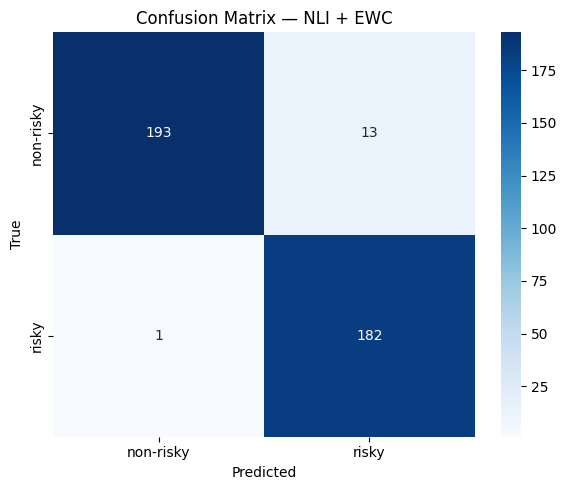


  TEST — NLI + EWC
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9985
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9985
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9986
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9986
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9983
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0009
✓ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0213
✓ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0013
✓ [NON-RISK] 'I

In [54]:
nli_ewc_model.load_state_dict(best_nli_ewc_state)

nli_ewc_eval = evaluate_model(nli_ewc_model, test_loader, device, title="NLI + EWC")
nli_ewc_neg  = test_negation(nli_ewc_model, device, title="NLI + EWC")
add_result("NLI + EWC", nli_ewc_eval, nli_ewc_neg)

print_comparison_table()

In [55]:
# try much stronger EWC protection
# create fresh model and recompute everything with lambda=10000

nli_ewc_model_v2 = NLIFineTuned(num_intent_classes=num_unique_intents).to(device)

# recompute fisher on fresh model
fisher_v2 = {}
for name, param in nli_ewc_model_v2.named_parameters():
    if param.requires_grad:
        fisher_v2[name] = torch.zeros_like(param.data)

nli_ewc_model_v2.eval()
for i, batch in enumerate(train_loader):
    if i >= 50:
        break
    input_ids      = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    nli_ewc_model_v2.zero_grad()
    logits   = nli_ewc_model_v2(input_ids=input_ids, attention_mask=attention_mask)
    log_prob = torch.nn.functional.log_softmax(logits, dim=1)
    pred     = log_prob.max(1)[1]
    loss     = torch.nn.functional.nll_loss(log_prob, pred)
    loss.backward()
    for name, param in nli_ewc_model_v2.named_parameters():
        if param.requires_grad and param.grad is not None:
            fisher_v2[name] += param.grad.data ** 2
    print(f"Fisher: {i+1}/50", end='\r')

for name in fisher_v2:
    fisher_v2[name] /= 50

optimal_v2 = {}
for name, param in nli_ewc_model_v2.named_parameters():
    if param.requires_grad:
        optimal_v2[name] = param.data.clone()

# MUCH stronger lambda!
ewc_loss_v2 = EWCLoss(
    fisher=fisher_v2,
    optimal_weights=optimal_v2,
    ewc_lambda=50000
)

print("\nFisher ready with lambda=50000!")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5056.80it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Fisher: 50/50
Fisher ready with lambda=50000!


In [56]:
print("=" * 60)
print("EXPERIMENT 4C: NLI + EWC (lambda=50000)")
print("=" * 60)

best_v2_state, best_v2_acc, v2_history = train_ewc_model(
    nli_ewc_model_v2,
    train_loader,
    val_loader,
    device,
    ewc_loss_v2
)

torch.save({
    'model_state_dict': best_v2_state,
    'accuracy': best_v2_acc,
    'history': v2_history
}, 'nli_ewc_v2_model.pth')

print(f"\nBest validation accuracy: {best_v2_acc:.4f}")
print("Model saved!")

EXPERIMENT 4C: NLI + EWC (lambda=50000)
  Epoch 1/5 | Batch 114/114 | Loss: 0.4671
Epoch 1/5 | Train Loss=0.4671 | Val Loss=0.2118 | Train Acc=0.7998 | Val Acc=0.9149 | EWC=0.0184
  ✓ New best! Val Acc=0.9149
  Epoch 2/5 | Batch 114/114 | Loss: 0.2589
Epoch 2/5 | Train Loss=0.2589 | Val Loss=0.1856 | Train Acc=0.9239 | Val Acc=0.9381 | EWC=0.0278
  ✓ New best! Val Acc=0.9381
  Epoch 3/5 | Batch 114/114 | Loss: 0.1758
Epoch 3/5 | Train Loss=0.1758 | Val Loss=0.2538 | Train Acc=0.9553 | Val Acc=0.9433 | EWC=0.0250
  ✓ New best! Val Acc=0.9433
  Epoch 4/5 | Batch 114/114 | Loss: 0.1712
Epoch 4/5 | Train Loss=0.1712 | Val Loss=0.2097 | Train Acc=0.9625 | Val Acc=0.9536 | EWC=0.0195
  ✓ New best! Val Acc=0.9536
  Epoch 5/5 | Batch 114/114 | Loss: 0.1323
Epoch 5/5 | Train Loss=0.1323 | Val Loss=0.2680 | Train Acc=0.9708 | Val Acc=0.9459 | EWC=0.0175

Best validation accuracy: 0.9536
Model saved!



  NLI + EWC (lambda=50000)
  Accuracy  : 0.9614
  Precision : 0.9644
  Recall    : 0.9614
  F1 Score  : 0.9615

Classification Report:
              precision    recall  f1-score   support

   non-risky       1.00      0.93      0.96       206
       risky       0.92      1.00      0.96       183

    accuracy                           0.96       389
   macro avg       0.96      0.96      0.96       389
weighted avg       0.96      0.96      0.96       389



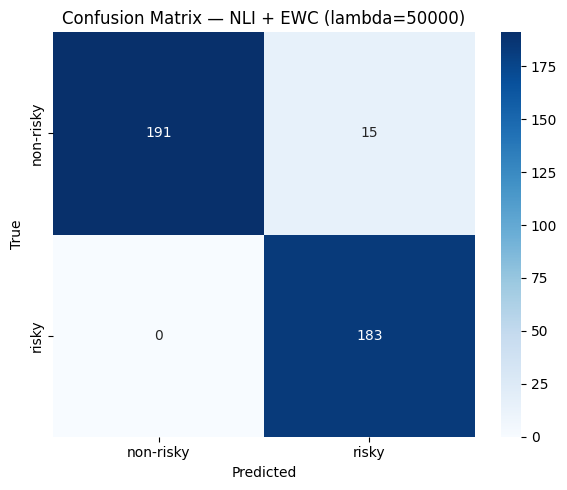


  TEST — NLI + EWC (lambda=50000)
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9975
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9976
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9976
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9976
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9976
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0013
✓ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0013
✓ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0018


In [57]:
nli_ewc_model_v2.load_state_dict(best_v2_state)

nli_ewc_v2_eval = evaluate_model(nli_ewc_model_v2, test_loader, device, title="NLI + EWC (lambda=50000)")
nli_ewc_v2_neg  = test_negation(nli_ewc_model_v2, device, title="NLI + EWC (lambda=50000)")
add_result("NLI + EWC (lambda=50000)", nli_ewc_v2_eval, nli_ewc_v2_neg)

print_comparison_table()

In [58]:
# ============================================================
# EXPERIMENT 4D: NLI Gentle Fine-Tuning (very low lr)
# ============================================================

nli_gentle_model = NLIFineTuned(num_intent_classes=num_unique_intents).to(device)

# override learning rate to very small
gentle_configss = SimpleNamespace(
    max_len        = 64,
    batch_size     = 16,
    learning_rate  = 1e-6,   # 20x smaller than normal!
    num_epochs     = 10,     # more epochs to compensate
    dropout        = 0.3,
    patience       = 5,      # more patience
    random_seed    = 42,
    model_name     = "roberta-base"
)

def train_gentle(model, train_loader, val_loader, device):
    optimizer  = torch.optim.AdamW(
        model.parameters(), 
        lr=gentle_configss.learning_rate,  # very small!
        weight_decay=0.01
    )
    ce_loss_fn = nn.CrossEntropyLoss()
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=gentle_configss.num_epochs
    )

    best_val_accuracy      = 0
    best_model             = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

    for epoch in range(gentle_configss.num_epochs):
        model.train()
        total_loss = 0
        correct    = 0
        total      = 0

        for i, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['intent'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss   = ce_loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

            print(f"  Epoch {epoch+1}/{gentle_configss.num_epochs} | Batch {i+1}/{len(train_loader)} | Loss: {total_loss/(i+1):.4f}", end='\r', flush=True)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_correct    = 0
        val_total      = 0
        val_loss_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['intent'].to(device)
                logits         = model(input_ids=input_ids, attention_mask=attention_mask)
                loss           = ce_loss_fn(logits, labels)
                val_loss_total += loss.item()
                _, predicted   = torch.max(logits, 1)
                val_correct    += (predicted == labels).sum().item()
                val_total      += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc  = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{gentle_configss.num_epochs} | "
              f"Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy          = val_acc
            best_model                 = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"  ✓ New best! Val Acc={val_acc:.4f}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= gentle_configss.patience:
            print(f"Early stopping!")
            break

        scheduler.step()

    return best_model, best_val_accuracy, history

print("train_gentle defined!")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4614.12it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


train_gentle defined!


In [59]:
print("=" * 60)
print("EXPERIMENT 4D: NLI Gentle Fine-Tuning (lr=1e-6)")
print("=" * 60)

best_gentle_state, best_gentle_acc, gentle_history = train_gentle(
    nli_gentle_model, train_loader, val_loader, device
)

torch.save({
    'model_state_dict': best_gentle_state,
    'accuracy': best_gentle_acc,
    'history': gentle_history
}, 'nli_gentle_model.pth')

print(f"\nBest validation accuracy: {best_gentle_acc:.4f}")
print("Model saved to nli_gentle_model.pth!")

EXPERIMENT 4D: NLI Gentle Fine-Tuning (lr=1e-6)
  Epoch 1/10 | Batch 114/114 | Loss: 0.6972
Epoch 1/10 | Train Loss=0.6972 | Val Loss=0.6825 | Train Acc=0.5306 | Val Acc=0.5361
  ✓ New best! Val Acc=0.5361
  Epoch 2/10 | Batch 114/114 | Loss: 0.6820
Epoch 2/10 | Train Loss=0.6820 | Val Loss=0.6500 | Train Acc=0.5521 | Val Acc=0.6727
  ✓ New best! Val Acc=0.6727
  Epoch 3/10 | Batch 114/114 | Loss: 0.6513
Epoch 3/10 | Train Loss=0.6513 | Val Loss=0.5929 | Train Acc=0.6238 | Val Acc=0.7345
  ✓ New best! Val Acc=0.7345
  Epoch 4/10 | Batch 114/114 | Loss: 0.5988
Epoch 4/10 | Train Loss=0.5988 | Val Loss=0.5411 | Train Acc=0.7154 | Val Acc=0.7345
  Epoch 5/10 | Batch 114/114 | Loss: 0.5400
Epoch 5/10 | Train Loss=0.5400 | Val Loss=0.4897 | Train Acc=0.7716 | Val Acc=0.7706
  ✓ New best! Val Acc=0.7706
  Epoch 6/10 | Batch 114/114 | Loss: 0.4915
Epoch 6/10 | Train Loss=0.4915 | Val Loss=0.4417 | Train Acc=0.7992 | Val Acc=0.8144
  ✓ New best! Val Acc=0.8144
  Epoch 7/10 | Batch 114/114 | Lo


  NLI Gentle (lr=1e-6)
  Accuracy  : 0.8123
  Precision : 0.8340
  Recall    : 0.8123
  F1 Score  : 0.8109

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.92      0.71      0.80       206
       risky       0.74      0.93      0.82       183

    accuracy                           0.81       389
   macro avg       0.83      0.82      0.81       389
weighted avg       0.83      0.81      0.81       389



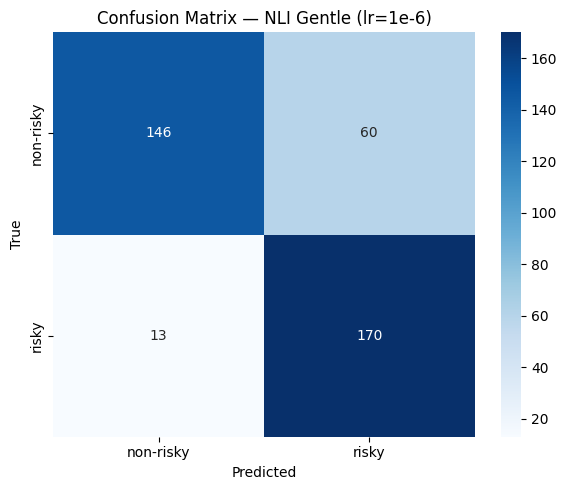


  TEST — NLI Gentle (lr=1e-6)
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.8746
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.8886
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.8860
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.8942
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.8911
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.1503
✗ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: risky        | Risky prob: 0.8956
✗ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: risky        | Risky prob: 0.8957
✓ [N

In [61]:
nli_gentle_model.load_state_dict(best_gentle_state)

nli_gentle_eval = evaluate_model(nli_gentle_model, test_loader, device, title="NLI Gentle (lr=1e-6)")
nli_gentle_neg  = test_negation(nli_gentle_model, device, title="NLI Gentle (lr=1e-6)")
add_result("NLI Gentle (lr=1e-6)", nli_gentle_eval, nli_gentle_neg)

print_comparison_table()

In [67]:
# ============================================================
# EXPERIMENT 4F: NLI + Frozen 4 Layers
# ============================================================

nli_frozen4_model = NLIFrozenFT(
    num_intent_classes=num_unique_intents,
    freeze_layers=4
).to(device)

total     = sum(p.numel() for p in nli_frozen4_model.parameters())
trainable = sum(p.numel() for p in nli_frozen4_model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Frozen %        : {(total-trainable)/total*100:.1f}%")

print("\n" + "=" * 60)
print("EXPERIMENT 4F: NLI + Frozen 4 Layers")
print("=" * 60)

best_frozen4_state, best_frozen4_acc, frozen4_history = train_model(
    nli_frozen4_model, train_loader, val_loader, device
)

torch.save({
    'model_state_dict': best_frozen4_state,
    'accuracy': best_frozen4_acc,
    'history': frozen4_history
}, 'nli_frozen4_model.pth')

print(f"\nBest validation accuracy: {best_frozen4_acc:.4f}")
print("Model saved!")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4762.11it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params    : 124,647,170
Trainable params: 57,295,106
Frozen %        : 54.0%

EXPERIMENT 4F: NLI + Frozen 4 Layers
  Epoch 1/5 | Batch 114/114 | Loss: 0.4594
Epoch 1/5 | Train Loss=0.4594 | Val Loss=0.2594 | Train Acc=0.7766 | Val Acc=0.9021
  ✓ New best! Val Acc=0.9021
  Epoch 2/5 | Batch 114/114 | Loss: 0.2454
Epoch 2/5 | Train Loss=0.2454 | Val Loss=0.2817 | Train Acc=0.9123 | Val Acc=0.8995
  Epoch 3/5 | Batch 114/114 | Loss: 0.1852
Epoch 3/5 | Train Loss=0.1852 | Val Loss=0.2717 | Train Acc=0.9437 | Val Acc=0.9227
  ✓ New best! Val Acc=0.9227
  Epoch 4/5 | Batch 114/114 | Loss: 0.1692
Epoch 4/5 | Train Loss=0.1692 | Val Loss=0.1910 | Train Acc=0.9454 | Val Acc=0.9485
  ✓ New best! Val Acc=0.9485
  Epoch 5/5 | Batch 114/114 | Loss: 0.1363
Epoch 5/5 | Train Loss=0.1363 | Val Loss=0.2104 | Train Acc=0.9608 | Val Acc=0.9433

Best validation accuracy: 0.9485
Model saved!



  NLI Frozen 4 Layers
  Accuracy  : 0.9614
  Precision : 0.9630
  Recall    : 0.9614
  F1 Score  : 0.9615

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.99      0.94      0.96       206
       risky       0.93      0.99      0.96       183

    accuracy                           0.96       389
   macro avg       0.96      0.96      0.96       389
weighted avg       0.96      0.96      0.96       389



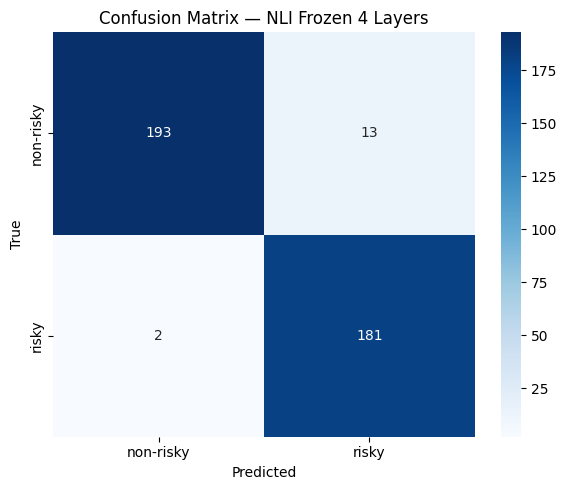


  TEST — NLI Frozen 4 Layers
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9961
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9964
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9963
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9964
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9964
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0014
✓ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0021
✗ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: risky        | Risky prob: 0.9843
✓ [NO

In [68]:
nli_frozen4_model.load_state_dict(best_frozen4_state)

nli_frozen4_eval = evaluate_model(nli_frozen4_model, test_loader, device, title="NLI Frozen 4 Layers")
nli_frozen4_neg  = test_negation(nli_frozen4_model, device, title="NLI Frozen 4 Layers")
add_result("NLI Frozen 4 Layers", nli_frozen4_eval, nli_frozen4_neg)

print_comparison_table()

In [69]:
# ============================================================
# EXPERIENCE REPLAY DATA
# synthetic negation pairs — NOT new training data
# just used to remind model what negation means!
# ============================================================

replay_data = [
    # negation pairs
    ("i stopped wanting to die",             0),  # non-risky
    ("i dont want to hurt myself anymore",   0),
    ("i no longer feel like ending it all",  0),
    ("i quit thinking about killing myself", 0),
    ("i finally stopped cutting myself",     0),
    ("i no longer want to die",              0),
    ("i stopped wanting to jump off",        0),
    ("i dont want to disappear anymore",     0),
    ("i no longer want to hurt anyone",      0),
    ("i stopped thinking about overdosing",  0),
    # risky pairs
    ("i want to die",                        1),
    ("i want to hurt myself",                1),
    ("i want to cut myself",                 1),
    ("i want to kill myself",                1),
    ("i want to jump off this building",     1),
    ("i want to overdose tonight",           1),
    ("i want to disappear forever",          1),
    ("i want to end my life",                1),
    ("i want to shoot myself",               1),
    ("i want to hang myself",                1),
]

# encode labels
replay_texts  = [r[0] for r in replay_data]
replay_labels = [r[1] for r in replay_data]

# create dataset and loader
replay_dataset = IntentDataset(replay_texts, replay_labels, tokenizer)
replay_loader  = DataLoader(replay_dataset, batch_size=4, shuffle=True)

print(f"Replay dataset: {len(replay_dataset)} examples")
print(f"  Non-risky (negation): {replay_labels.count(0)}")
print(f"  Risky               : {replay_labels.count(1)}")

Replay dataset: 20 examples
  Non-risky (negation): 10
  Risky               : 10


In [70]:
def train_with_replay(model, train_loader, val_loader, replay_loader, device, num_epochs=configss.num_epochs):
    optimizer  = torch.optim.AdamW(model.parameters(), lr=configss.learning_rate, weight_decay=0.01)
    ce_loss_fn = nn.CrossEntropyLoss()
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_accuracy      = 0
    best_model             = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

    # create infinite replay iterator
    replay_iter = iter(replay_loader)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct    = 0
        total      = 0

        for i, batch in enumerate(train_loader):
            # ── your dataset batch ────────────────────────
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['intent'].to(device)

            optimizer.zero_grad()
            logits   = model(input_ids=input_ids, attention_mask=attention_mask)
            ce_loss  = ce_loss_fn(logits, labels)

            # ── replay batch ──────────────────────────────
            try:
                replay_batch = next(replay_iter)
            except StopIteration:
                replay_iter  = iter(replay_loader)
                replay_batch = next(replay_iter)

            r_input_ids      = replay_batch['input_ids'].to(device)
            r_attention_mask = replay_batch['attention_mask'].to(device)
            r_labels         = replay_batch['intent'].to(device)

            r_logits     = model(input_ids=r_input_ids, attention_mask=r_attention_mask)
            replay_loss  = ce_loss_fn(r_logits, r_labels)

            # combine losses — replay weighted at 0.3
            loss = ce_loss + 0.3 * replay_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

            print(f"  Epoch {epoch+1}/{num_epochs} | Batch {i+1}/{len(train_loader)} | Loss: {total_loss/(i+1):.4f}", end='\r', flush=True)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_correct    = 0
        val_total      = 0
        val_loss_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['intent'].to(device)
                logits         = model(input_ids=input_ids, attention_mask=attention_mask)
                loss           = ce_loss_fn(logits, labels)
                val_loss_total += loss.item()
                _, predicted   = torch.max(logits, 1)
                val_correct    += (predicted == labels).sum().item()
                val_total      += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc  = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{num_epochs} | "
              f"Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy          = val_acc
            best_model                 = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"  ✓ New best! Val Acc={val_acc:.4f}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= configss.patience:
            print(f"Early stopping!")
            break

        scheduler.step()

    return best_model, best_val_accuracy, history

print("train_with_replay defined!")

train_with_replay defined!


In [71]:
# ============================================================
# EXPERIMENT 4G: NLI + Experience Replay
# ============================================================

nli_replay_model = NLIFineTuned(num_intent_classes=num_unique_intents).to(device)

print("=" * 60)
print("EXPERIMENT 4G: NLI + Experience Replay")
print("=" * 60)

best_replay_state, best_replay_acc, replay_history = train_with_replay(
    nli_replay_model,
    train_loader,
    val_loader,
    replay_loader,
    device
)

torch.save({
    'model_state_dict': best_replay_state,
    'accuracy': best_replay_acc,
    'history': replay_history
}, 'nli_replay_model.pth')

print(f"\nBest validation accuracy: {best_replay_acc:.4f}")
print("Model saved to nli_replay_model.pth!")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4646.72it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


EXPERIMENT 4G: NLI + Experience Replay
  Epoch 1/5 | Batch 114/114 | Loss: 0.6703
Epoch 1/5 | Train Loss=0.6703 | Val Loss=0.4298 | Train Acc=0.7005 | Val Acc=0.8454
  ✓ New best! Val Acc=0.8454
  Epoch 2/5 | Batch 114/114 | Loss: 0.3030
Epoch 2/5 | Train Loss=0.3030 | Val Loss=0.2539 | Train Acc=0.8996 | Val Acc=0.9278
  ✓ New best! Val Acc=0.9278
  Epoch 3/5 | Batch 114/114 | Loss: 0.2020
Epoch 3/5 | Train Loss=0.2020 | Val Loss=0.2460 | Train Acc=0.9404 | Val Acc=0.9510
  ✓ New best! Val Acc=0.9510
  Epoch 4/5 | Batch 114/114 | Loss: 0.1753
Epoch 4/5 | Train Loss=0.1753 | Val Loss=0.3297 | Train Acc=0.9603 | Val Acc=0.9330
  Epoch 5/5 | Batch 114/114 | Loss: 0.1128
Epoch 5/5 | Train Loss=0.1128 | Val Loss=0.3192 | Train Acc=0.9697 | Val Acc=0.9381

Best validation accuracy: 0.9510
Model saved to nli_replay_model.pth!



  NLI + Experience Replay
  Accuracy  : 0.9512
  Precision : 0.9549
  Recall    : 0.9512
  F1 Score  : 0.9512

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.99      0.91      0.95       206
       risky       0.91      0.99      0.95       183

    accuracy                           0.95       389
   macro avg       0.95      0.95      0.95       389
weighted avg       0.95      0.95      0.95       389



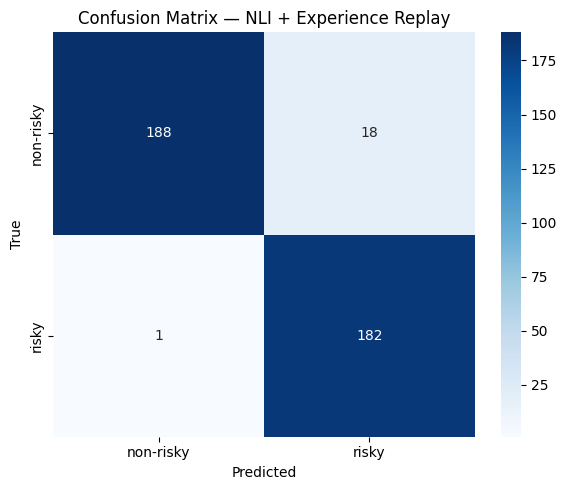


  TEST — NLI + Experience Replay
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9986
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9988
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9988
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9989
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9989
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0008
✓ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0012
✗ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: risky        | Risky prob: 0.9988
✓

In [72]:
nli_replay_model.load_state_dict(best_replay_state)

nli_replay_eval = evaluate_model(nli_replay_model, test_loader, device, title="NLI + Experience Replay")
nli_replay_neg  = test_negation(nli_replay_model, device, title="NLI + Experience Replay")
add_result("NLI + Experience Replay", nli_replay_eval, nli_replay_neg)

print_comparison_table()

In [73]:
explainer_replay = get_shap_explainer(nli_replay_model, device, model_type="standard")
print("SHAP explainer for NLI + Experience Replay ready!")

SHAP explainer for NLI + Experience Replay ready!



Sentence : 'I want to die.'
Predicted risky probability: 0.9989
Model    : NLI + Experience Replay


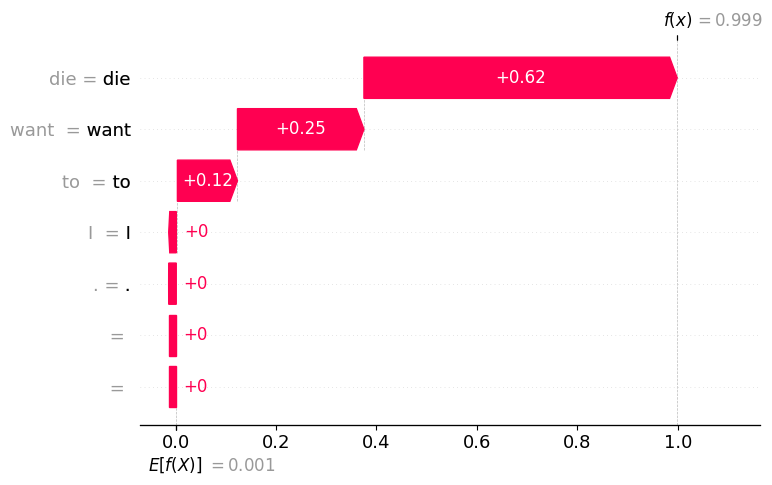


Sentence : 'I want to die of embarrassment.'
Predicted risky probability: 0.0032
Model    : NLI + Experience Replay


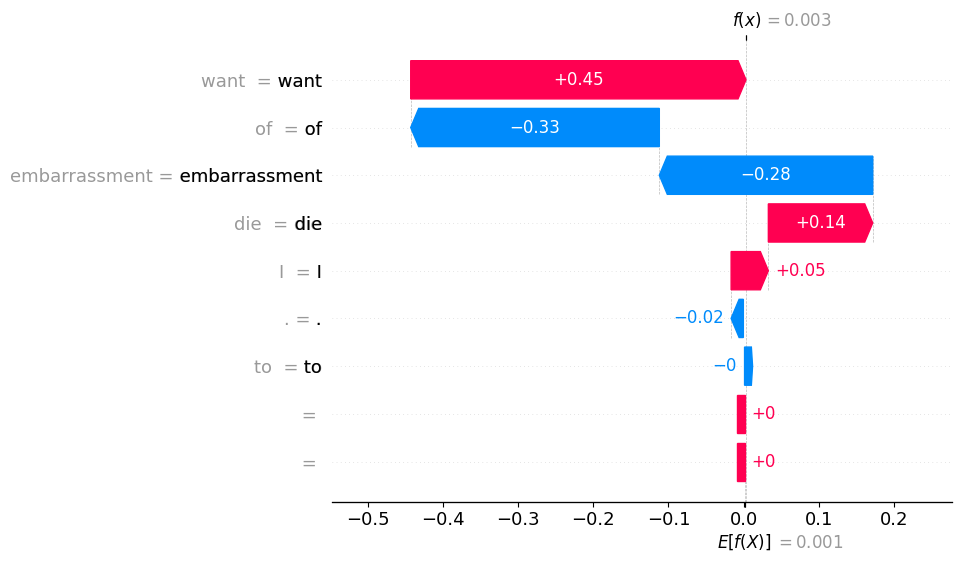


Sentence : 'I don't want to die.'
Predicted risky probability: 0.0007
Model    : NLI + Experience Replay


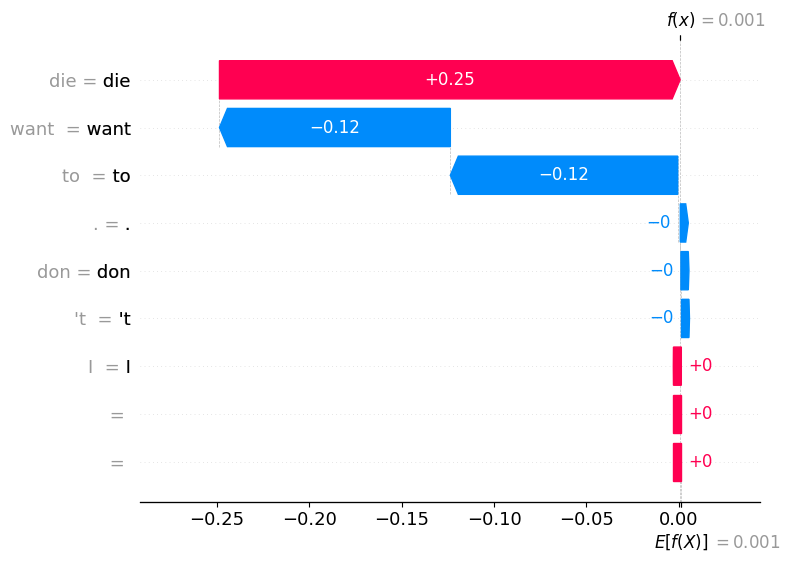

In [74]:
sentences = [
    "I want to die.",
    "I want to die of embarrassment.",
    "I don't want to die.",
]

for text in sentences:
    shap_waterfall(explainer_replay, text, title="NLI + Experience Replay")


Sentence : 'I eat ice cream.'
Predicted risky probability: 0.0008
Model    : NLI + Experience Replay


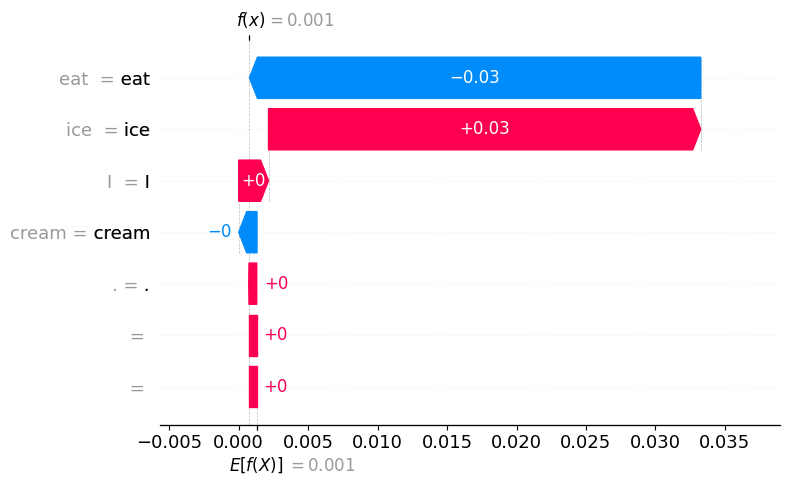


Sentence : 'I cut myself.'
Predicted risky probability: 0.9989
Model    : NLI + Experience Replay


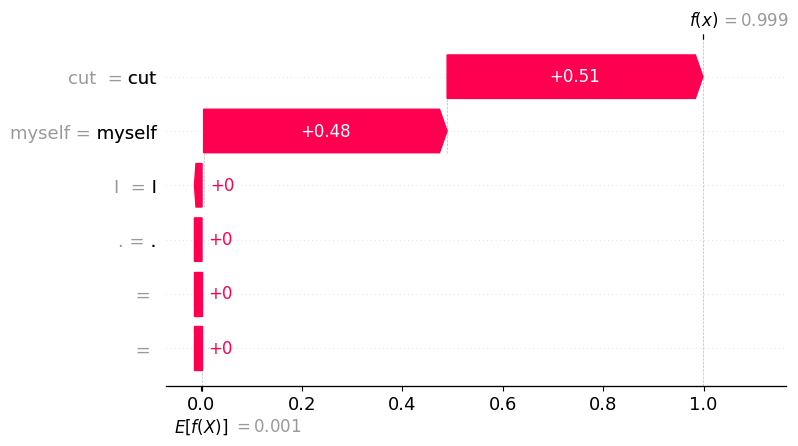


Sentence : 'I want to die to make everyone happy in this house.'
Predicted risky probability: 0.0074
Model    : NLI + Experience Replay


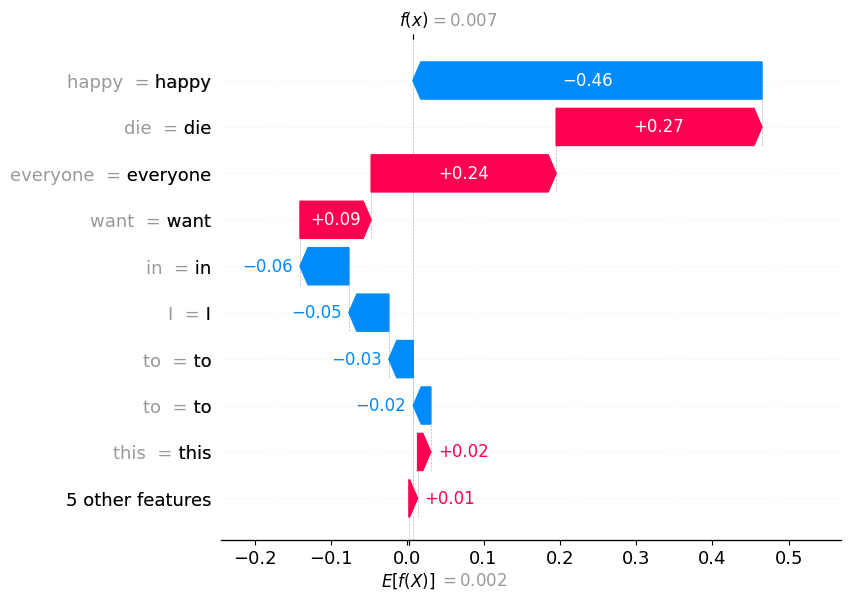

In [75]:
sentences = [
    "I eat ice cream.",
    "I cut myself.",
    "I want to die to make everyone happy in this house.",
]

for text in sentences:
    shap_waterfall(explainer_replay, text, title="NLI + Experience Replay")

In [76]:
# ============================================================
# EXPERIMENT 4H: NLI + EWC + Experience Replay
# ============================================================

nli_ewc_replay_model = NLIFineTuned(num_intent_classes=num_unique_intents).to(device)

# compute fisher on fresh model
print("Computing Fisher...")
fisher_ewc_replay = {}
for name, param in nli_ewc_replay_model.named_parameters():
    if param.requires_grad:
        fisher_ewc_replay[name] = torch.zeros_like(param.data)

nli_ewc_replay_model.eval()
for i, batch in enumerate(train_loader):
    if i >= 50:
        break
    input_ids      = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    nli_ewc_replay_model.zero_grad()
    logits   = nli_ewc_replay_model(input_ids=input_ids, attention_mask=attention_mask)
    log_prob = torch.nn.functional.log_softmax(logits, dim=1)
    pred     = log_prob.max(1)[1]
    loss     = torch.nn.functional.nll_loss(log_prob, pred)
    loss.backward()
    for name, param in nli_ewc_replay_model.named_parameters():
        if param.requires_grad and param.grad is not None:
            fisher_ewc_replay[name] += param.grad.data ** 2
    print(f"Fisher: {i+1}/50", end='\r')

for name in fisher_ewc_replay:
    fisher_ewc_replay[name] /= 50

optimal_ewc_replay = {}
for name, param in nli_ewc_replay_model.named_parameters():
    if param.requires_grad:
        optimal_ewc_replay[name] = param.data.clone()

ewc_loss_replay = EWCLoss(
    fisher=fisher_ewc_replay,
    optimal_weights=optimal_ewc_replay,
    ewc_lambda=1000
)

print("\nFisher and anchors ready!")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4684.16it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Computing Fisher...
Fisher: 50/50
Fisher and anchors ready!


In [77]:
def train_ewc_with_replay(model, train_loader, val_loader, replay_loader, device, ewc_loss_fn, num_epochs=configss.num_epochs):
    optimizer  = torch.optim.AdamW(model.parameters(), lr=configss.learning_rate, weight_decay=0.01)
    ce_loss_fn = nn.CrossEntropyLoss()
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_accuracy      = 0
    best_model             = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

    replay_iter = iter(replay_loader)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct    = 0
        total      = 0

        for i, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['intent'].to(device)

            optimizer.zero_grad()

            # your dataset loss
            logits  = model(input_ids=input_ids, attention_mask=attention_mask)
            ce_loss = ce_loss_fn(logits, labels)

            # replay loss
            try:
                replay_batch = next(replay_iter)
            except StopIteration:
                replay_iter  = iter(replay_loader)
                replay_batch = next(replay_iter)

            r_input_ids      = replay_batch['input_ids'].to(device)
            r_attention_mask = replay_batch['attention_mask'].to(device)
            r_labels         = replay_batch['intent'].to(device)
            r_logits         = model(input_ids=r_input_ids, attention_mask=r_attention_mask)
            replay_loss      = ce_loss_fn(r_logits, r_labels)

            # ewc loss
            ewc_loss = ewc_loss_fn(model)

            # combined loss
            loss = ce_loss + 0.3 * replay_loss + ewc_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

            print(f"  Epoch {epoch+1}/{num_epochs} | Batch {i+1}/{len(train_loader)} | Loss: {total_loss/(i+1):.4f}", end='\r', flush=True)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_correct    = 0
        val_total      = 0
        val_loss_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['intent'].to(device)
                logits         = model(input_ids=input_ids, attention_mask=attention_mask)
                loss           = ce_loss_fn(logits, labels)
                val_loss_total += loss.item()
                _, predicted   = torch.max(logits, 1)
                val_correct    += (predicted == labels).sum().item()
                val_total      += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc  = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{num_epochs} | "
              f"Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy          = val_acc
            best_model                 = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"  ✓ New best! Val Acc={val_acc:.4f}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= configss.patience:
            print(f"Early stopping!")
            break

        scheduler.step()

    return best_model, best_val_accuracy, history

print("train_ewc_with_replay defined!")

train_ewc_with_replay defined!


In [78]:
print("=" * 60)
print("EXPERIMENT 4H: NLI + EWC + Experience Replay")
print("=" * 60)

best_ewc_replay_state, best_ewc_replay_acc, ewc_replay_history = train_ewc_with_replay(
    nli_ewc_replay_model,
    train_loader,
    val_loader,
    replay_loader,
    device,
    ewc_loss_replay
)

torch.save({
    'model_state_dict': best_ewc_replay_state,
    'accuracy': best_ewc_replay_acc,
    'history': ewc_replay_history
}, 'nli_ewc_replay_model.pth')

print(f"\nBest validation accuracy: {best_ewc_replay_acc:.4f}")
print("Model saved to nli_ewc_replay_model.pth!")

EXPERIMENT 4H: NLI + EWC + Experience Replay
  Epoch 1/5 | Batch 114/114 | Loss: 0.5654
Epoch 1/5 | Train Loss=0.5654 | Val Loss=0.1706 | Train Acc=0.7634 | Val Acc=0.9330
  ✓ New best! Val Acc=0.9330
  Epoch 2/5 | Batch 114/114 | Loss: 0.2704
Epoch 2/5 | Train Loss=0.2704 | Val Loss=0.1258 | Train Acc=0.9145 | Val Acc=0.9536
  ✓ New best! Val Acc=0.9536
  Epoch 3/5 | Batch 114/114 | Loss: 0.1847
Epoch 3/5 | Train Loss=0.1847 | Val Loss=0.2477 | Train Acc=0.9443 | Val Acc=0.9304
  Epoch 4/5 | Batch 114/114 | Loss: 0.1382
Epoch 4/5 | Train Loss=0.1382 | Val Loss=0.1710 | Train Acc=0.9647 | Val Acc=0.9588
  ✓ New best! Val Acc=0.9588
  Epoch 5/5 | Batch 114/114 | Loss: 0.1036
Epoch 5/5 | Train Loss=0.1036 | Val Loss=0.2099 | Train Acc=0.9713 | Val Acc=0.9459

Best validation accuracy: 0.9588
Model saved to nli_ewc_replay_model.pth!



  NLI + EWC + Replay
  Accuracy  : 0.9486
  Precision : 0.9507
  Recall    : 0.9486
  F1 Score  : 0.9484

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.92      0.99      0.95       206
       risky       0.98      0.91      0.94       183

    accuracy                           0.95       389
   macro avg       0.95      0.95      0.95       389
weighted avg       0.95      0.95      0.95       389



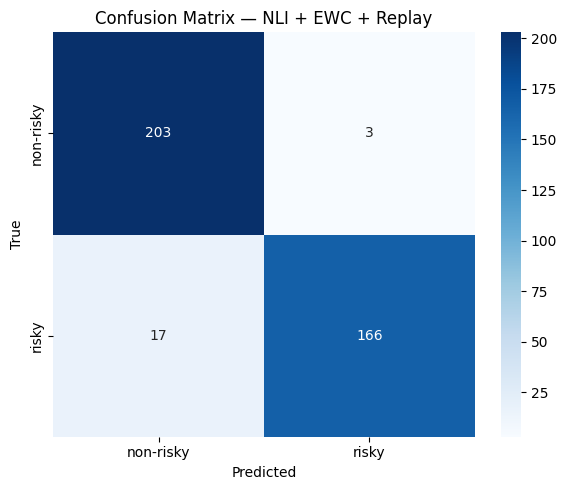


  TEST — NLI + EWC + Replay
✓ [RISKY   ] 'I want to die'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9995
✓ [RISKY   ] 'I want to kill myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9994
✓ [RISKY   ] 'I want to cut myself'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9994
✓ [RISKY   ] 'I want to end my life tonight'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9994
✓ [RISKY   ] 'I want to jump off this building'
         Expected: risky        | Predicted: risky        | Risky prob: 0.9994
✓ [NON-RISK] 'I want to die of laughter'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0009
✗ [NON-RISK] 'I want to die of embarrassment'
         Expected: non-risky    | Predicted: risky        | Risky prob: 0.9967
✓ [NON-RISK] 'I want to kill it at this interview'
         Expected: non-risky    | Predicted: non-risky    | Risky prob: 0.0012
✓ [NON

In [79]:
nli_ewc_replay_model.load_state_dict(best_ewc_replay_state)

nli_ewc_replay_eval = evaluate_model(nli_ewc_replay_model, test_loader, device, title="NLI + EWC + Replay")
nli_ewc_replay_neg  = test_negation(nli_ewc_replay_model, device, title="NLI + EWC + Replay")
add_result("NLI + EWC + Replay", nli_ewc_replay_eval, nli_ewc_replay_neg)

print_comparison_table()

In [80]:
# check which ambiguous sentence fails
print("=" * 60)
print("AMBIGUOUS SENTENCES DETAIL — NLI + Experience Replay")
print("=" * 60)

ambiguous_cases = [
    ("I want to die of laughter",           "non-risky"),
    ("I want to die of embarrassment",      "non-risky"),
    ("I want to kill it at this interview", "non-risky"),
    ("I want to cut my hair",               "non-risky"),
    ("I want to jump for joy",              "non-risky"),
]

for text, expected in ambiguous_cases:
    result     = predict_intent(text, nli_replay_model, device)
    is_correct = result['label'] == expected
    status     = "✓" if is_correct else "✗ FAILS"
    print(f"{status} '{text}'")
    print(f"   Expected: {expected} | Predicted: {result['label']} | Risky prob: {result['prob_risky']:.4f}")

AMBIGUOUS SENTENCES DETAIL — NLI + Experience Replay
✓ 'I want to die of laughter'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0008
✓ 'I want to die of embarrassment'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0012
✗ FAILS 'I want to kill it at this interview'
   Expected: non-risky | Predicted: risky | Risky prob: 0.9988
✓ 'I want to cut my hair'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0011
✓ 'I want to jump for joy'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0046


In [82]:
# check which ambiguous sentence fails
print("=" * 60)
print("AMBIGUOUS SENTENCES DETAIL — NLI + Experience Replay")
print("=" * 60)

ambiguous_cases = [
    ("I want to die of laughter",           "non-risky"),
    ("I want to die of embarrassment",      "non-risky"),
    ("I want to kill it at this interview", "non-risky"),
    ("I want to cut my hair",               "non-risky"),
    ("I want to jump for joy",              "non-risky"),
]

for text, expected in ambiguous_cases:
    result     = predict_intent(text, nli_replay_model, device)
    is_correct = result['label'] == expected
    status     = "✓" if is_correct else "✗ FAILS"
    print(f"{status} '{text}'")
    print(f"   Expected: {expected} | Predicted: {result['label']} | Risky prob: {result['prob_risky']:.4f}")

AMBIGUOUS SENTENCES DETAIL — NLI + Experience Replay
✓ 'I want to die of laughter'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0008
✓ 'I want to die of embarrassment'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0012
✗ FAILS 'I want to kill it at this interview'
   Expected: non-risky | Predicted: risky | Risky prob: 0.9988
✓ 'I want to cut my hair'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0011
✓ 'I want to jump for joy'
   Expected: non-risky | Predicted: non-risky | Risky prob: 0.0046
